
# Random Forest Baseline — Incident Classification

This notebook trains and evaluates a **Random Forest classifier** for the fixed three-class task:

- `NORMAL`
- `ACCIDENT`
- `OTHER_DISRUPTION`

It uses the revised canonical dataset and two frozen evaluation settings:

1. **Grouped-random split**
2. **Spatial holdout split**

The primary model-selection metric is **validation Macro-F1**. The test set is evaluated only after the best hyperparameters have been selected.

`all_zero_flow_window`, identifiers, station IDs, timestamps, and target-derived columns are retained only for auditing and are **not** used as predictors.


In [1]:

# Optional installation if a package is missing:
# !pip install pandas numpy scikit-learn matplotlib joblib

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]

# Change only DATA_DIR if the files are stored elsewhere.
DATA_DIR = Path(".")

CANONICAL_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/canonical_dataset_revised.csv")
GROUPED_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")
SPATIAL_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/spatial_split_manifest_revised.csv")

OUTPUT_DIR = DATA_DIR / "random_forest_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [CANONICAL_PATH, GROUPED_MANIFEST_PATH, SPATIAL_MANIFEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing file: {p.resolve()}\n"
            "Place this notebook in the same folder as the three revised CSV files "
            "or update DATA_DIR above."
        )

print("Canonical:", CANONICAL_PATH.resolve())
print("Grouped manifest:", GROUPED_MANIFEST_PATH.resolve())
print("Spatial manifest:", SPATIAL_MANIFEST_PATH.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


Canonical: /Users/andishahifahmuthahharah/Downloads/revised_core_dataset_final/canonical_dataset_revised.csv
Grouped manifest: /Users/andishahifahmuthahharah/Downloads/revised_core_dataset_final/grouped_random_split_manifest_revised.csv
Spatial manifest: /Users/andishahifahmuthahharah/Downloads/revised_core_dataset_final/spatial_split_manifest_revised.csv
Output directory: /Users/andishahifahmuthahharah/Downloads/random_forest_outputs


## 1. Load and validate the fixed data

In [2]:

canonical = pd.read_csv(CANONICAL_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

print("Canonical shape:", canonical.shape)
print("Grouped manifest shape:", grouped_manifest.shape)
print("Spatial manifest shape:", spatial_manifest.shape)

print("\nClass distribution:")
display(
    canonical["target_class"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .to_frame("count")
)

assert canonical["event_sample_id"].is_unique, "Duplicate event_sample_id in canonical dataset."
assert grouped_manifest["event_sample_id"].is_unique, "Duplicate event_sample_id in grouped manifest."
assert spatial_manifest["event_sample_id"].is_unique, "Duplicate event_sample_id in spatial manifest."

assert set(canonical["event_sample_id"]) == set(grouped_manifest["event_sample_id"]),     "Grouped manifest mismatch."
assert set(canonical["event_sample_id"]) == set(spatial_manifest["event_sample_id"]),     "Spatial manifest mismatch."

assert set(canonical["target_class"].unique()) == set(CLASS_ORDER),     "Unexpected target classes."
assert set(grouped_manifest["split"].unique()) == {"train", "validation", "test"}
assert set(spatial_manifest["split"].unique()) == {"train", "validation", "test"}

print("\nAll basic integrity checks passed.")


Canonical shape: (5265, 16)
Grouped manifest shape: (5265, 5)
Spatial manifest shape: (5265, 5)

Class distribution:


,count
target_class,
NORMAL,3581
ACCIDENT,505
OTHER_DISRUPTION,1179



All basic integrity checks passed.


## 2. Feature engineering

In [3]:

FLOW_COLS = [
    "flow_t_minus_3",
    "flow_t_minus_2",
    "flow_t_minus_1",
    "flow_t0",
    "flow_t_plus_1",
    "flow_t_plus_2",
    "flow_t_plus_3",
]

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create leakage-safe traffic-only tabular features."""

    missing = [c for c in FLOW_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing flow columns: {missing}")

    flow = df[FLOW_COLS].astype(float).to_numpy()

    if not np.isfinite(flow).all():
        raise ValueError("Flow matrix contains NaN or infinite values.")
    if (flow < 0).any():
        raise ValueError("Negative flow values found.")

    X = pd.DataFrame(index=df.index)

    # Log-compressed hourly flow
    for j, col in enumerate(FLOW_COLS):
        X[f"log1p_{col}"] = np.log1p(flow[:, j])

    # Consecutive differences and stabilized relative changes
    diffs = np.diff(flow, axis=1)
    denom = np.maximum(np.abs(flow[:, :-1]), 1.0)
    rel = np.clip(diffs / denom, -10.0, 10.0)

    step_names = [
        "m3_to_m2",
        "m2_to_m1",
        "m1_to_t0",
        "t0_to_p1",
        "p1_to_p2",
        "p2_to_p3",
    ]

    for j, name in enumerate(step_names):
        X[f"diff_{name}"] = diffs[:, j]
        X[f"rel_change_{name}"] = rel[:, j]

    pre = flow[:, :3]
    response = flow[:, 3:]

    X["pre_mean"] = pre.mean(axis=1)
    X["response_mean"] = response.mean(axis=1)
    X["mean_shift"] = X["response_mean"] - X["pre_mean"]
    X["response_pre_ratio"] = X["response_mean"] / np.maximum(X["pre_mean"], 1.0)

    X["onset_jump"] = flow[:, 3] - flow[:, 2]
    X["pre_slope"] = (flow[:, 2] - flow[:, 0]) / 2.0
    X["response_slope"] = (flow[:, 6] - flow[:, 3]) / 3.0

    X["window_mean"] = flow.mean(axis=1)
    X["window_std"] = flow.std(axis=1)
    X["window_min"] = flow.min(axis=1)
    X["window_max"] = flow.max(axis=1)
    X["window_range"] = X["window_max"] - X["window_min"]

    X["max_drop"] = np.minimum(diffs, 0).min(axis=1)
    X["max_rise"] = np.maximum(diffs, 0).max(axis=1)
    X["max_abs_change"] = np.abs(diffs).max(axis=1)
    X["cumulative_post_change"] = flow[:, 6] - flow[:, 3]

    if not np.isfinite(X.to_numpy()).all():
        raise ValueError("Engineered features contain NaN or infinite values.")

    return X

X_all = build_features(canonical)
y_all = canonical["target_class"].astype(str)

print("Feature matrix shape:", X_all.shape)
display(X_all.head())


Feature matrix shape: (5265, 35)


,log1p_flow_t_minus_3,log1p_flow_t_minus_2,log1p_flow_t_minus_1,log1p_flow_t0,log1p_flow_t_plus_1,log1p_flow_t_plus_2,log1p_flow_t_plus_3,diff_m3_to_m2,rel_change_m3_to_m2,diff_m2_to_m1,rel_change_m2_to_m1,diff_m1_to_t0,rel_change_m1_to_t0,diff_t0_to_p1,rel_change_t0_to_p1,diff_p1_to_p2,rel_change_p1_to_p2,diff_p2_to_p3,rel_change_p2_to_p3,pre_mean,response_mean,mean_shift,response_pre_ratio,onset_jump,pre_slope,response_slope,window_mean,window_std,window_min,window_max,window_range,max_drop,max_rise,max_abs_change,cumulative_post_change
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.639057,1.609438,2.639057,2.397895,2.833213,2.564949,2.079442,-9.0,-0.692308,9.0,2.25,-3.0,-0.230769,6.0,0.600000,-4.0,-0.250000,-5.0,-0.416667,10.000000,11.25,1.250000,1.125000,-3.0,0.0,-1.000000,10.714286,3.768830,4.0,16.0,12.0,-9.0,9.0,9.0,-3.0
3,0.000000,0.000000,3.465736,2.995732,3.433987,3.332205,0.000000,0.0,0.000000,31.0,10.00,-12.0,-0.387097,11.0,0.578947,-3.0,-0.100000,-27.0,-1.000000,10.333333,19.00,8.666667,1.838710,-12.0,15.5,-6.333333,15.285714,13.708332,0.0,31.0,31.0,-27.0,31.0,31.0,-19.0
4,3.091042,3.433987,3.526361,3.555348,4.304065,4.663439,5.081404,9.0,0.428571,3.0,0.10,1.0,0.030303,39.0,1.147059,32.0,0.438356,55.0,0.523810,28.000000,93.00,65.000000,3.321429,1.0,6.0,42.000000,65.142857,47.561775,21.0,160.0,139.0,0.0,55.0,55.0,126.0



## 3. Model selection and evaluation

A compact hyperparameter grid is evaluated on the validation set.

Selection priority:

1. highest validation Macro-F1;
2. highest validation balanced accuracy;
3. fewer trees and shallower depth as tie-breakers.

The test set is not used during model selection.


In [4]:

PARAM_GRID = [
    {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "max_features": max_features,
        "class_weight": class_weight,
    }
    for n_estimators in [300, 600]
    for max_depth in [None, 10, 20]
    for min_samples_leaf in [2, 5, 10]
    for max_features in ["sqrt", 0.5]
    for class_weight in ["balanced", "balanced_subsample"]
]

def merge_split(canonical_df: pd.DataFrame, manifest: pd.DataFrame) -> pd.DataFrame:
    manifest_small = manifest[["event_sample_id", "target_class", "split"]].copy()

    merged = canonical_df.merge(
        manifest_small,
        on="event_sample_id",
        how="inner",
        suffixes=("", "_manifest"),
        validate="one_to_one",
    )

    assert len(merged) == len(canonical_df), "Manifest merge lost rows."
    assert (
        merged["target_class"] == merged["target_class_manifest"]
    ).all(), "Target mismatch after merge."

    return merged.drop(columns="target_class_manifest")

def metric_row(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

def run_random_forest_experiment(split_name: str, manifest: pd.DataFrame):
    data = merge_split(canonical, manifest)
    X = build_features(data)
    y = data["target_class"].astype(str)

    masks = {
        part: data["split"].eq(part).to_numpy()
        for part in ["train", "validation", "test"]
    }

    X_train, y_train = X.loc[masks["train"]], y.loc[masks["train"]]
    X_val, y_val = X.loc[masks["validation"]], y.loc[masks["validation"]]
    X_test, y_test = X.loc[masks["test"]], y.loc[masks["test"]]

    print(f"\n=== {split_name} ===")
    print("Train / validation / test:", len(y_train), len(y_val), len(y_test))

    split_counts = (
        data.groupby(["split", "target_class"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=["train", "validation", "test"], columns=CLASS_ORDER, fill_value=0)
    )
    display(split_counts)

    search_rows = []
    models = []

    for i, params in enumerate(PARAM_GRID, start=1):
        model = RandomForestClassifier(
            criterion="gini",
            bootstrap=True,
            oob_score=False,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            **params,
        )

        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)

        row = {
            **params,
            **metric_row(y_val, val_pred),
        }

        search_rows.append(row)
        models.append(model)

        if i % 10 == 0 or i == len(PARAM_GRID):
            print(f"Evaluated {i}/{len(PARAM_GRID)} parameter combinations")

    search_df = pd.DataFrame(search_rows)

    # Preserve None as readable text in output tables.
    search_df["max_depth_display"] = search_df["max_depth"].apply(
        lambda x: "None" if pd.isna(x) else str(int(x))
    )

    ranking = search_df.sort_values(
        ["macro_f1", "balanced_accuracy", "n_estimators"],
        ascending=[False, False, True],
    )

    best_idx = ranking.index[0]
    best_model = models[best_idx]
    best_params = PARAM_GRID[best_idx]

    print("\nBest validation parameters:")
    print(best_params)

    display(
        ranking[
            [
                "n_estimators",
                "max_depth_display",
                "min_samples_leaf",
                "max_features",
                "class_weight",
                "accuracy",
                "balanced_accuracy",
                "macro_f1",
                "weighted_f1",
            ]
        ].head(10)
    )

    partition_results = []
    prediction_frames = []

    for part, X_part, y_part in [
        ("train", X_train, y_train),
        ("validation", X_val, y_val),
        ("test", X_test, y_test),
    ]:
        pred = best_model.predict(X_part)

        partition_results.append(
            {
                "split_scheme": split_name,
                "partition": part,
                **metric_row(y_part, pred),
            }
        )

        ids = data.loc[masks[part], "event_sample_id"].to_numpy()
        prediction_frames.append(
            pd.DataFrame(
                {
                    "event_sample_id": ids,
                    "split_scheme": split_name,
                    "partition": part,
                    "y_true": y_part.to_numpy(),
                    "y_pred": pred,
                }
            )
        )

    results_df = pd.DataFrame(partition_results)
    prediction_df = pd.concat(prediction_frames, ignore_index=True)

    test_pred = prediction_df.loc[
        prediction_df["partition"].eq("test"), "y_pred"
    ].to_numpy()

    print("\nOverall metrics:")
    display(results_df)

    print("\nTest classification report:")
    report = classification_report(
        y_test,
        test_pred,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    display(report_df)

    safe_name = split_name.lower().replace("-", "_").replace(" ", "_")

    search_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_hyperparameter_search.csv",
        index=False,
    )
    results_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_metrics.csv",
        index=False,
    )
    report_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_test_classification_report.csv"
    )
    prediction_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_predictions.csv",
        index=False,
    )

    with open(OUTPUT_DIR / f"{safe_name}_best_params.json", "w") as f:
        json.dump(best_params, f, indent=2)

    joblib.dump(
        best_model,
        OUTPUT_DIR / f"{safe_name}_random_forest.joblib",
    )

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_pred,
        labels=CLASS_ORDER,
        display_labels=CLASS_ORDER,
        cmap=None,
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"Random Forest — {split_name} test confusion matrix")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{safe_name}_confusion_matrix.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    # Feature importance
    importance_df = pd.DataFrame(
        {
            "feature": X.columns,
            "importance": best_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    importance_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_feature_importance.csv",
        index=False,
    )

    display(importance_df.head(20))

    top = importance_df.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top["feature"], top["importance"])
    ax.set_title(f"Random Forest — {split_name} feature importance")
    ax.set_xlabel("Gini importance")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{safe_name}_feature_importance.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    return {
        "model": best_model,
        "best_params": best_params,
        "metrics": results_df,
        "report": report_df,
        "predictions": prediction_df,
        "importance": importance_df,
        "search": search_df,
    }


## 4. Grouped-random experiment


=== Grouped-random ===
Train / validation / test: 3685 784 796


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2510,352,823
validation,530,79,175
test,541,74,181


Evaluated 10/72 parameter combinations
Evaluated 20/72 parameter combinations
Evaluated 30/72 parameter combinations
Evaluated 40/72 parameter combinations
Evaluated 50/72 parameter combinations
Evaluated 60/72 parameter combinations
Evaluated 70/72 parameter combinations
Evaluated 72/72 parameter combinations

Best validation parameters:
{'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}


,n_estimators,max_depth_display,min_samples_leaf,max_features,class_weight,accuracy,balanced_accuracy,macro_f1,weighted_f1
33,300,20,10,sqrt,balanced_subsample,0.483418,0.329277,0.321554,0.492850
44,600,None,10,sqrt,balanced,0.493622,0.324338,0.317230,0.498829
32,300,20,10,sqrt,balanced,0.485969,0.321841,0.314576,0.493638
8,300,None,10,sqrt,balanced,0.484694,0.321212,0.313931,0.492594
16,300,10,5,sqrt,balanced,0.497449,0.323911,0.313869,0.498846
21,300,10,10,sqrt,balanced_subsample,0.459184,0.320917,0.313749,0.475249
9,300,None,10,sqrt,balanced_subsample,0.479592,0.322523,0.313742,0.488284
53,600,10,5,sqrt,balanced_subsample,0.502551,0.321323,0.312246,0.501018
68,600,20,10,sqrt,balanced,0.484694,0.317384,0.310904,0.490943
20,300,10,10,sqrt,balanced,0.452806,0.317773,0.310397,0.469398



Overall metrics:


,split_scheme,partition,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Grouped-random,train,0.767978,0.794661,0.751665,0.783134
1,Grouped-random,validation,0.483418,0.329277,0.321554,0.492850
2,Grouped-random,test,0.512563,0.361513,0.352011,0.519985



Test classification report:


,precision,recall,f1-score,support
NORMAL,0.686848,0.608133,0.645098,541.000000
ACCIDENT,0.128205,0.067568,0.088496,74.000000
OTHER_DISRUPTION,0.266187,0.408840,0.322440,181.000000
accuracy,0.512563,0.512563,0.512563,0.512563
macro avg,0.360413,0.361513,0.352011,796.000000
weighted avg,0.539261,0.512563,0.519985,796.000000


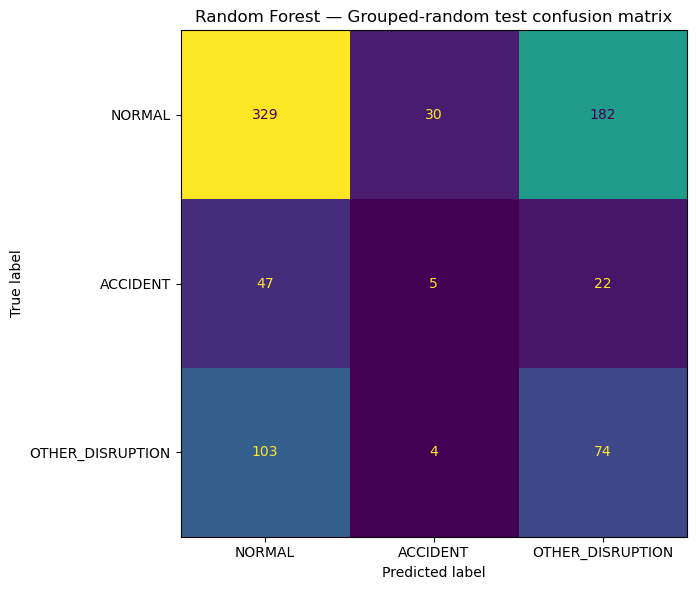

,feature,importance
18,rel_change_p2_to_p3,0.036380
16,rel_change_p1_to_p2,0.036034
8,rel_change_m3_to_m2,0.035159
15,diff_p1_to_p2,0.033652
12,rel_change_m1_to_t0,0.032783
14,rel_change_t0_to_p1,0.031898
22,response_pre_ratio,0.031838
25,response_slope,0.031110
21,mean_shift,0.030904
10,rel_change_m2_to_m1,0.030756


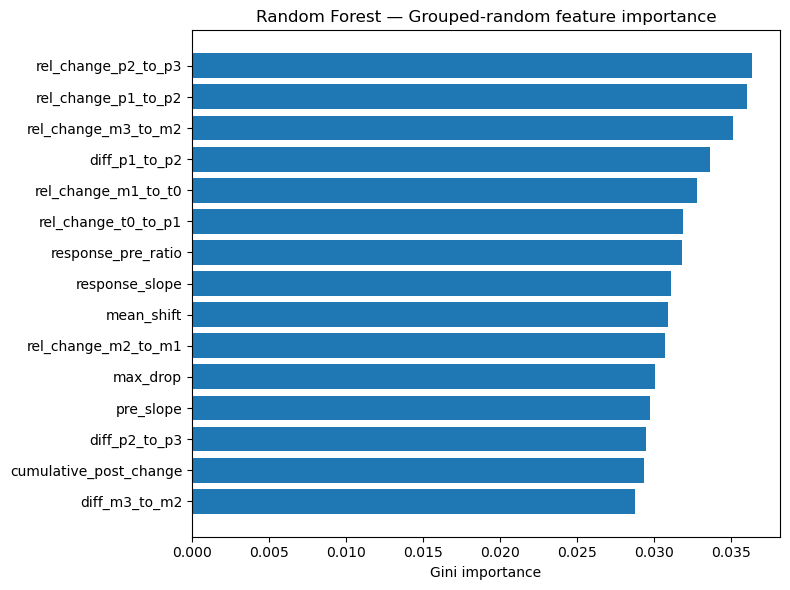

In [5]:

grouped_results = run_random_forest_experiment(
    split_name="Grouped-random",
    manifest=grouped_manifest,
)


## 5. Spatial holdout experiment


=== Spatial holdout ===
Train / validation / test: 3703 806 756


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2517,347,839
validation,549,84,173
test,515,74,167


Evaluated 10/72 parameter combinations
Evaluated 20/72 parameter combinations
Evaluated 30/72 parameter combinations
Evaluated 40/72 parameter combinations
Evaluated 50/72 parameter combinations
Evaluated 60/72 parameter combinations
Evaluated 70/72 parameter combinations
Evaluated 72/72 parameter combinations

Best validation parameters:
{'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}


,n_estimators,max_depth_display,min_samples_leaf,max_features,class_weight,accuracy,balanced_accuracy,macro_f1,weighted_f1
28,300,20,5,sqrt,balanced,0.562035,0.360945,0.347705,0.550003
5,300,None,5,sqrt,balanced_subsample,0.559553,0.361050,0.347645,0.548704
8,300,None,10,sqrt,balanced,0.498759,0.357342,0.347360,0.513053
69,600,20,10,sqrt,balanced_subsample,0.504963,0.358336,0.347328,0.517504
9,300,None,10,sqrt,balanced_subsample,0.504963,0.357017,0.346474,0.517957
4,300,None,5,sqrt,balanced,0.559553,0.359730,0.346249,0.547586
35,300,20,10,0.5,balanced_subsample,0.504963,0.352460,0.346147,0.515304
7,300,None,5,0.5,balanced_subsample,0.564516,0.358200,0.345690,0.549795
66,600,20,5,0.5,balanced,0.565757,0.357488,0.345237,0.550880
6,300,None,5,0.5,balanced,0.566998,0.356775,0.344537,0.551065



Overall metrics:


,split_scheme,partition,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Spatial holdout,train,0.840940,0.865020,0.835151,0.851535
1,Spatial holdout,validation,0.562035,0.360945,0.347705,0.550003
2,Spatial holdout,test,0.478836,0.351646,0.313425,0.485006



Test classification report:


,precision,recall,f1-score,support
NORMAL,0.690955,0.533981,0.602410,515.000000
ACCIDENT,0.000000,0.000000,0.000000,74.000000
OTHER_DISRUPTION,0.250000,0.520958,0.337864,167.000000
accuracy,0.478836,0.478836,0.478836,0.478836
macro avg,0.313652,0.351646,0.313425,756.000000
weighted avg,0.525915,0.478836,0.485006,756.000000


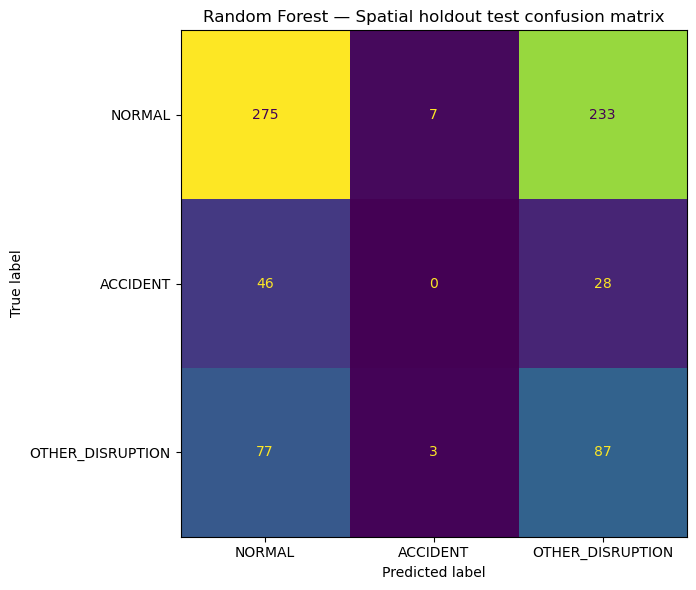

,feature,importance
8,rel_change_m3_to_m2,0.039297
18,rel_change_p2_to_p3,0.036556
16,rel_change_p1_to_p2,0.034464
15,diff_p1_to_p2,0.033002
10,rel_change_m2_to_m1,0.032998
12,rel_change_m1_to_t0,0.032603
14,rel_change_t0_to_p1,0.032300
17,diff_p2_to_p3,0.030866
13,diff_t0_to_p1,0.030707
7,diff_m3_to_m2,0.030705


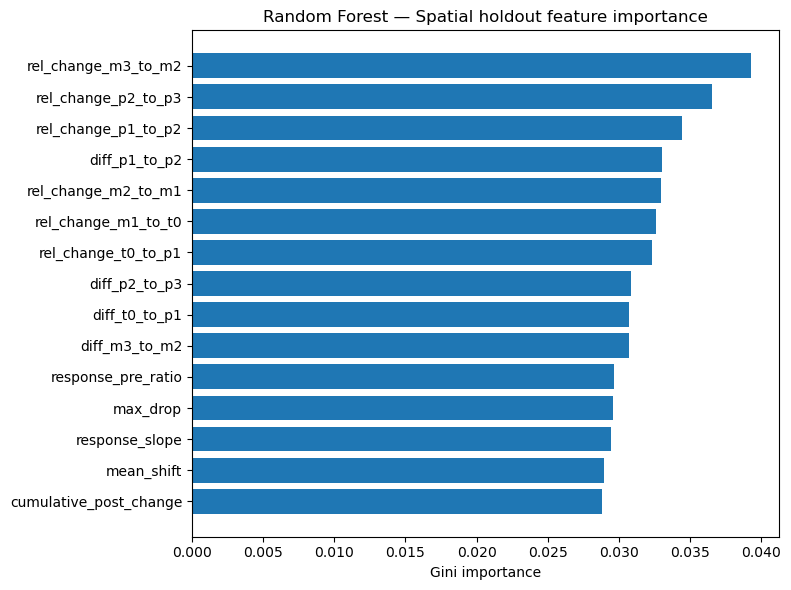

In [6]:

spatial_results = run_random_forest_experiment(
    split_name="Spatial holdout",
    manifest=spatial_manifest,
)


## 6. Final comparison

In [7]:

comparison = pd.concat(
    [grouped_results["metrics"], spatial_results["metrics"]],
    ignore_index=True,
)

comparison.to_csv(
    OUTPUT_DIR / "random_forest_all_metrics.csv",
    index=False,
)

test_comparison = comparison[
    comparison["partition"].eq("test")
].reset_index(drop=True)

print("Test-set comparison:")
display(test_comparison)

print("\nSaved files:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print("-", p.name)


Test-set comparison:


,split_scheme,partition,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Grouped-random,test,0.512563,0.361513,0.352011,0.519985
1,Spatial holdout,test,0.478836,0.351646,0.313425,0.485006



Saved files:
- grouped_random_best_params.json
- grouped_random_confusion_matrix.png
- grouped_random_feature_importance.csv
- grouped_random_feature_importance.png
- grouped_random_hyperparameter_search.csv
- grouped_random_metrics.csv
- grouped_random_predictions.csv
- grouped_random_random_forest.joblib
- grouped_random_test_classification_report.csv
- random_forest_all_metrics.csv
- spatial_holdout_best_params.json
- spatial_holdout_confusion_matrix.png
- spatial_holdout_feature_importance.csv
- spatial_holdout_feature_importance.png
- spatial_holdout_hyperparameter_search.csv
- spatial_holdout_metrics.csv
- spatial_holdout_predictions.csv
- spatial_holdout_random_forest.joblib
- spatial_holdout_test_classification_report.csv



## Interpretation guidance

Focus on:

- test Macro-F1 and balanced accuracy;
- recall and F1 for `ACCIDENT` and `OTHER_DISRUPTION`;
- the confusion matrix, especially `NORMAL → OTHER_DISRUPTION` and `ACCIDENT → OTHER_DISRUPTION`;
- the gap between grouped-random and spatial holdout performance;
- whether Random Forest improves over the Decision Tree thresholds:
  - grouped-random Macro-F1: **0.303**
  - spatial holdout Macro-F1: **0.253**

Random Forest does not use epoch-based early stopping. Overfitting is controlled through tree depth, leaf size, feature subsampling, bootstrap aggregation, and validation-based hyperparameter selection.
